# MLPR LAB 8
### Proshita Agarwal

In [14]:
# step 1
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.semi_supervised import SelfTrainingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, balanced_accuracy_score
import seaborn as sns

In [2]:
# step 2
# Load the dataset
data = pd.read_csv('data.csv')

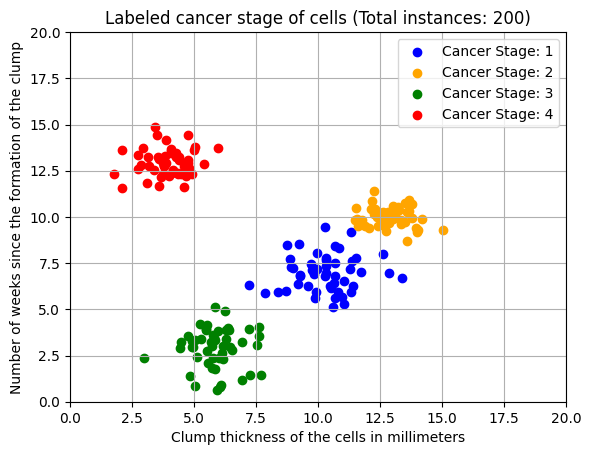

In [3]:
# step 3
colors = {1: 'blue', 2: 'orange', 3: 'green', 4: 'red'}

for stage in [1, 2, 3, 4]:
    subset = data[data['Cancer stage'] == stage]
    plt.scatter(subset['Clump thickness'], 
                subset['No of week'], 
                color=colors[stage], 
                label=f'Cancer Stage: {stage}')
plt.xlabel('Clump thickness of the cells in millimeters')
plt.ylabel('Number of weeks since the formation of the clump')
plt.title('Labeled cancer stage of cells (Total instances: 200)')
plt.xlim(0, 20)
plt.ylim(0, 20)
plt.grid(True)
plt.legend()
plt.show()

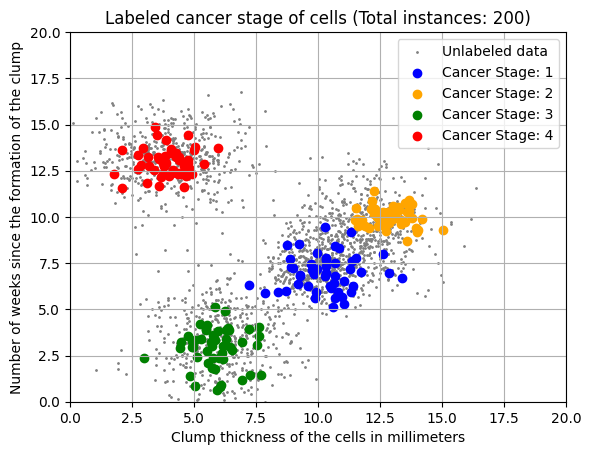

In [4]:
# step 4
plt.scatter(data['Clump thickness_new'], 
            data['No of week_new'],
            color = 'gray',
            s = 1,
            label = 'Unlabeled data')

colors = {1: 'blue', 2: 'orange', 3: 'green', 4: 'red'}

for stage in [1, 2, 3, 4]:
    subset = data[data['Cancer stage'] == stage]
    plt.scatter(subset['Clump thickness'], 
                subset['No of week'], 
                color=colors[stage], 
                label=f'Cancer Stage: {stage}')
plt.xlabel('Clump thickness of the cells in millimeters')
plt.ylabel('Number of weeks since the formation of the clump')
plt.title('Labeled cancer stage of cells (Total instances: 200)')
plt.xlim(0, 20)
plt.ylim(0, 20)
plt.grid(True)
plt.legend()
plt.show()

C:\Users\Proshita\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but SelfTrainingClassifier was fitted without feature names
  warnings.warn(


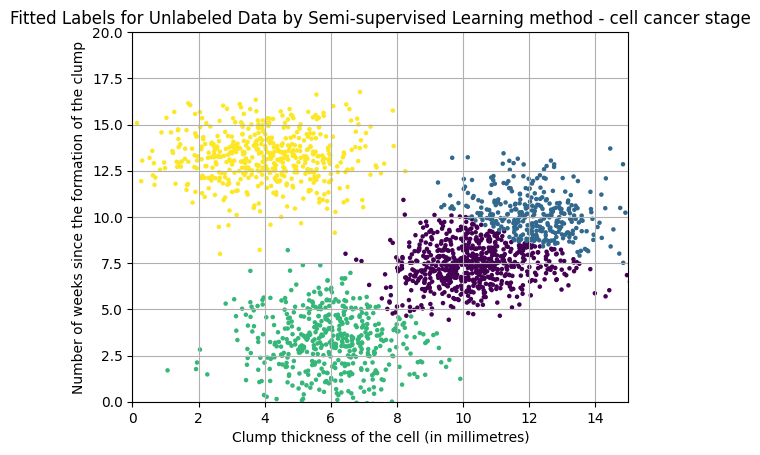

In [11]:
# step 5
# labeled rows only
labeled = data[data['Cancer stage'].notna()]

X_train = labeled[['Clump thickness','No of week']]
y_train = labeled['Cancer stage']

# unlabeled new datapoints
X_new = data[['Clump thickness_new','No of week_new']]

# rename columns so sklearn accepts them
X_new_model = X_new.copy()
X_new_model.columns = ['Clump thickness','No of week']

# combine labeled + unlabeled
X_all = np.vstack((X_train, X_new_model))
y_all = np.concatenate((y_train, [-1]*len(X_new_model)))

# model
knn = KNeighborsClassifier(n_neighbors=5)
model = SelfTrainingClassifier(knn)

# train
model.fit(X_all, y_all)

# predict labels for new datapoints
pred = model.predict(X_new_model)

# plot predictions
plt.scatter(data['Clump thickness_new'],
            data['No of week_new'],
            c=pred,
            cmap='viridis',
            s=5)

plt.xlim(0,15)
plt.ylim(0,20)
plt.grid(True)

plt.xlabel('Clump thickness of the cell (in millimetres)')
plt.ylabel('Number of weeks since the formation of the clump')
plt.title('Fitted Labels for Unlabeled Data by Semi-supervised Learning method - cell cancer stage')

plt.show()

Accuracy Score: 0.8915
Balanced Accuracy Score: 0.8915

Classification Report:

              precision    recall  f1-score   support

           1       0.71      0.98      0.82       500
           2       0.96      0.64      0.77       500
           3       1.00      0.96      0.98       500
           4       0.99      1.00      1.00       500

    accuracy                           0.89      2000
   macro avg       0.92      0.89      0.89      2000
weighted avg       0.92      0.89      0.89      2000



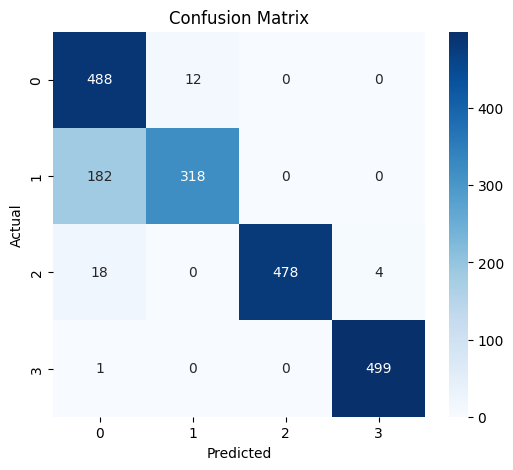

In [15]:
# step 6
# true labels
y_true = data['True cancer stage']

# accuracy
acc = accuracy_score(y_true, pred)
bal_acc = balanced_accuracy_score(y_true, pred)

print("Accuracy Score:", acc)
print("Balanced Accuracy Score:", bal_acc)

# classification report
print("\nClassification Report:\n")
print(classification_report(y_true, pred))

# confusion matrix
cm = confusion_matrix(y_true, pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

### REPORT

**1. Provide three applications of Semi-supervised learning.**

Semi-supervised learning is useful when only a small amount of labeled data is available but a large amount of unlabeled data exists.

Some common applications include:
- Medical image analysis, where labeling data requires expert doctors.
- Speech recognition, where large amounts of audio data are available but only some are transcribed.
- Spam detection or web page classification, where only a portion of emails or pages are labeled.


**2. What are the three assumptions of Semi-supervised learning?**

Semi-supervised learning relies on three main assumptions:

- **Smoothness assumption:** Data points that are close to each other are likely to have the same label.
- **Cluster assumption:** Data points tend to form clusters, and points in the same cluster belong to the same class.
- **Manifold assumption:** High-dimensional data often lies on a lower-dimensional structure called a manifold.


**3. What is the significance of these assumptions in Semi-supervised Learning?**

These assumptions help the model use unlabeled data effectively.

- The smoothness assumption ensures nearby points get similar labels.
- The cluster assumption helps identify groups of similar data points.
- The manifold assumption helps the model learn the underlying structure of the data.

Together, they improve the model’s ability to generalize from limited labeled data.


**4. How does Co-training differ from Self-training? Which usually performs better?**

In self-training, one model predicts labels for unlabeled data and adds the most confident predictions to its training set.

In co-training, two different models are trained on different feature sets and label new data for each other.

Co-training can sometimes perform better when two independent feature sets are available, but self-training is simpler and more commonly used.


**5. How to evaluate the performance of a semi-supervised learning method?**

The performance of a semi-supervised model can be evaluated using common classification metrics such as:

- Accuracy score
- Confusion matrix
- Classification report (precision, recall, F1-score)

These metrics help measure how well the model predicts the correct class labels.